In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys  
sys.path.insert(1, '/home/garrett/work/ChromoBoot/')
print(os.getcwd())
from rels_utils import get_dihedral_images, get_rel_instances_in_symb, replace_trivial0_terms
import json
api = wandb.Api()
plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams.update({'font.size': 15})
from collections import Counter, OrderedDict
import itertools
from itertools import islice

/home/garrett/work/ChromoBoot/notebooks


In [2]:
def is_sum_set(mylist):
    is_sum = False
    for x in range(len(mylist)):
        newlist = mylist[:x] + mylist[x+1:]
        if sum(abs(number) for number in newlist) == abs(mylist[x]): is_sum = True
    return is_sum

In [3]:
def same_sign(mylist):
    return all(i > 0 for i in mylist) or all(i < 0 for i in mylist)

In [4]:
is_sum_set([1,2,-3])

True

In [13]:
f2 = open("../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.triple0.boots.110")
data2=json.load(f2)

In [14]:
def get_tripvals(epoch):
    f = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.triple0.boots.{epoch}")
    data=json.load(f)

    myvals=list(data.values())
    myfinals=list(data2.values())

    counter = 0
    sumsets = 0
    samesigns = 0
    allpos = 0
    allneg = 0
    for i,val in enumerate(myvals):
        if i % 3 != 0: continue
        counter += 1
        mylist = [myvals[i],myvals[i+1],myvals[i+2]]
        if is_sum_set(mylist): sumsets += 1
        if same_sign(mylist): samesigns += 1
        if all(i > 0 for i in mylist): allpos += 1
        if all(i < 0 for i in mylist): allneg += 1
    return sumsets,samesigns,counter,allpos,allneg

In [15]:
def get_doublevals(epoch):
    f = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.final17.boots.{epoch}")
    data=json.load(f)

    myvals=list(data.values())
    myfinals=list(data2.values())

    counter = 0
    sumsets = 0
    samesigns = 0
    allpos = 0
    allneg = 0
    for i,val in enumerate(myvals):
        if i % 3 != 0: continue
        counter += 1
        mylist = [myvals[i],myvals[i+1],myvals[i+2]]
        if is_sum_set(mylist): sumsets += 1
        if same_sign(mylist): samesigns += 1
        if all(i > 0 for i in mylist): allpos += 1
        if all(i < 0 for i in mylist): allneg += 1
    return sumsets,samesigns,counter,allpos,allneg

In [16]:
counter = 0
badabs = 0
for i,val in enumerate(myvals):
    counter += 1
    if abs(myvals[i]) != abs(myfinals[i]):
        #print(myvals[i],myfinals[i])
        badabs += 1
print(badabs/counter)        

NameError: name 'myvals' is not defined

In [17]:
for i in range(110):
    sumsets,samesigns,counter,allpos,allneg = getvals(i)
    #print(sumsets,samesigns,counter,allpos,allneg)

NameError: name 'getvals' is not defined

In [6]:
def integchecker(epoch):
    f_lookup=open("../../ChromoBoot_data/processed_data/coef_from_word/relations_6loop_old2/rel_instances_integral1.json") 
    f = open(f"../../integchecker/checkpoint_6loop/htcondor/dumped/debug/1565321/eval.all_relations.boots.{epoch}")
    truth_instance_list=json.load(f_lookup)
    eval_symb=json.load(f)
    eval_symb=replace_trivial0_terms(eval_symb,True)
    eval_data = get_rel_instances_in_symb(truth_instance_list, eval_symb)
    
    
    counter=0
    type1_acc = 0
    type2_acc = 0
    type3_acc = 0
    type4_acc = 0
    type5_acc = 0
    mixed_acc = 0
    type1_tot = 0
    type2_tot = 0
    type3_tot = 0
    mixed_tot = 0
    for eval_values,truth_values in zip(eval_data,truth_instance_list):
        myvals=[val[0] for val in list(eval_values.values())]
        truthvals=[val[0] for val in list(truth_values.values())]
        if any(v is None for v in myvals): continue
        if len(myvals) != 4: raise ValueError
        counter += 1
        relcheck = myvals[0]+myvals[1]-myvals[2]-myvals[3]
        truth_relcheck = truthvals[0]+truthvals[1]-truthvals[2]-truthvals[3]
        #print(truth_relcheck)
        #if relcheck!=0: print(myvals,truthvals)
        if (truthvals[0])==(truthvals[2]):
            type1_tot += 1
            if relcheck==0:type1_acc += 1
        elif (truthvals[0])==(truthvals[3]):
            type2_tot += 1
            if relcheck==0:type2_acc += 1
        elif (truthvals[0])==(-truthvals[1]):
            type3_tot += 1
            if relcheck==0:type3_acc += 1
        else:
            mixed_tot += 1
            if relcheck==0:mixed_acc += 1
    
    overall_acc=type1_acc+type2_acc+type3_acc+mixed_acc
    #print(overall_acc)
    
    return type1_acc/type1_tot,type2_acc/type2_tot,type3_acc/type3_tot,mixed_acc/mixed_tot, overall_acc/counter

In [7]:
type1_accs=[]
type2_accs=[]
type3_accs=[]
mixed_accs=[]
overall_accs=[]
for i in range(200):
    type1_acc,type2_acc,type3_acc,mixed_acc,overall_acc = integchecker(i)
    type1_accs.append(type1_acc)
    type2_accs.append(type2_acc)
    type3_accs.append(type3_acc)
    mixed_accs.append(mixed_acc)
    overall_accs.append(overall_acc)

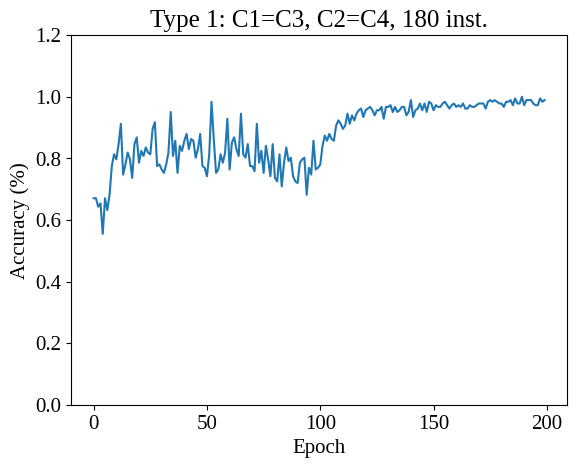

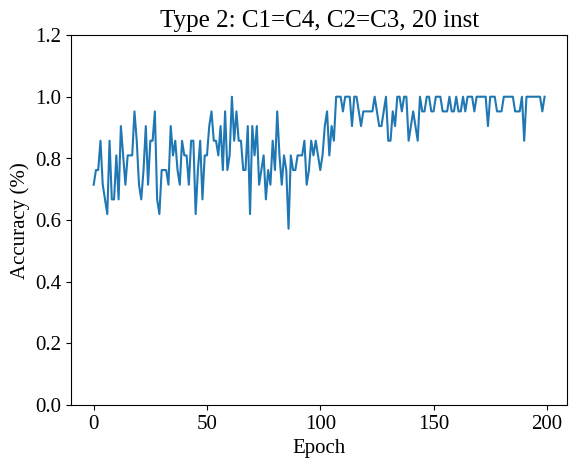

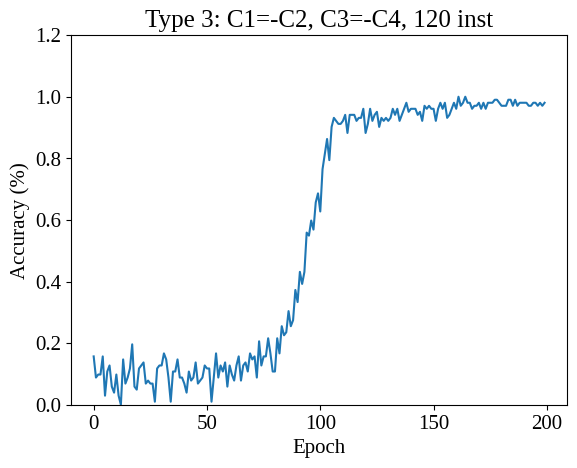

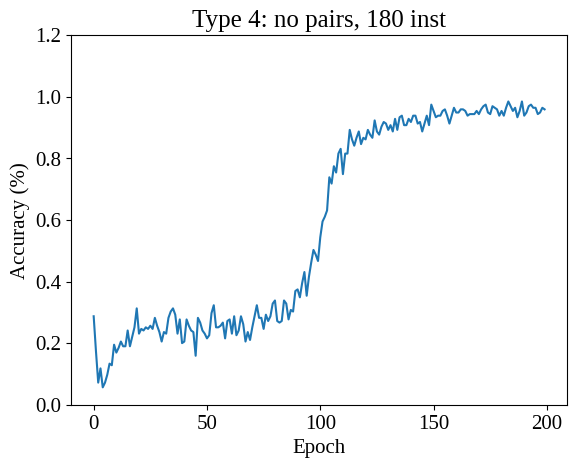

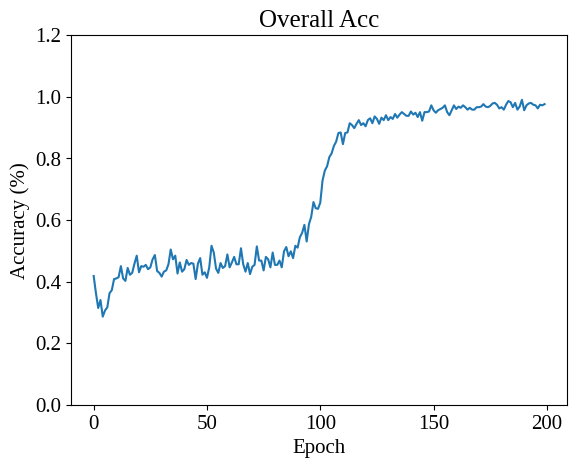

In [60]:
plt.plot(type1_accs)
plt.xlabel("Epoch")
plt.ylim([0,1.2])
plt.ylabel("Accuracy (%)")
plt.title("Type 1: C1=C3, C2=C4, 180 inst.")
plt.savefig("type1_integ1_accs.png")
plt.show()
plt.plot(type2_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim([0,1.2])
plt.title("Type 2: C1=C4, C2=C3, 20 inst")
plt.savefig("type2_integ1_accs.png")
plt.show()
plt.plot(type3_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim([0,1.2])
plt.title("Type 3: C1=-C2, C3=-C4, 120 inst")
plt.savefig("type3_integ1_accs.png")
plt.show()
plt.plot(mixed_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim([0,1.2])
plt.title("Type 4: no pairs, 180 inst")
plt.savefig("mixed_integ1_accs.png")
plt.show()
plt.plot(overall_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim([0,1.2])
plt.title("Overall Acc")
plt.savefig("overall_integ1_acc.png")
plt.show()

In [9]:
def signcounter(epoch):
    #file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.{epoch}")
    file = open(f"../../integchecker/checkpoint_6loop/htcondor/dumped/debug/1565321/eval.valid.boots.{epoch}")
    pred_pluses=0
    pred_minuses=0
    tgt_pluses=0
    tgt_minuses=0
    fullcounter=0
    counter=0
    acc=0

    with file as f:
        while True:
            next_n_lines = list(islice(f, 5))
            if not next_n_lines:
                break
            #if next_n_lines[3][0]=='1': continue
            #print(next_n_lines)
            word=next_n_lines[1][4:16]
            tgt=next_n_lines[2][4:-1]
            pred=next_n_lines[3][2:-1]
            data=[word, tgt, pred]
            try: num = int(pred)
            except ValueError: continue
            if int(pred) > 0: pred_pluses += 1
            if int(pred) < 0: pred_minuses += 1
            if int(tgt) > 0: tgt_pluses += 1
            if int(tgt) < 0: tgt_minuses += 1
            if int(tgt) != 0:
                counter += 1
                if pred == tgt: acc += 1
            fullcounter += 1
    pred_plusround = round(pred_pluses/counter,3)
    pred_minusround = round(pred_minuses/counter,3)
    pred_diff = round(pred_plusround - pred_minusround,3)
    tgt_plusround = round(tgt_pluses/counter,3)
    tgt_minusround = round(tgt_minuses/counter,3)
    tgt_diff = round(tgt_plusround - tgt_minusround,3)    
    pred_dominant = ("+" if pred_diff > 0 else "-")
    tgt_dominant = ("+" if tgt_diff > 0 else "-")
    #print(f"preds: {pred_plusround, pred_minusround, pred_diff, pred_dominant}")
    #print(f"tgt: {tgt_plusround, tgt_minusround, tgt_diff, tgt_dominant}")
    return acc/counter, pred_plusround, pred_minusround, tgt_plusround, tgt_minusround

In [10]:
totdiffs=0
my_acc= []
plus_pct=[]
minus_pct=[]
tgtplus_pct=[]
tgtminus_pct=[]
for i in range(200):
    #print(i)
    thisacc,pluspct,minuspct,tgtplus,tgtminus = signcounter(i)
    my_acc.append(thisacc)
    plus_pct.append(pluspct)
    minus_pct.append(minuspct)
    tgtplus_pct.append(tgtplus)
    tgtminus_pct.append(tgtminus)
    #if thisacc > 0.95: print(i)

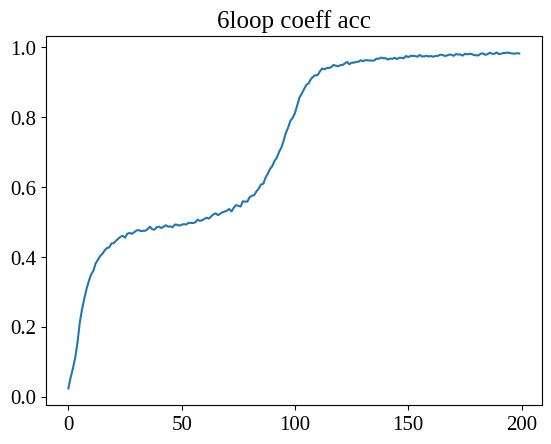

In [11]:
plt.plot(my_acc)
plt.title("6loop coeff acc")
plt.savefig("acc_curve_test_6loop_512.png")

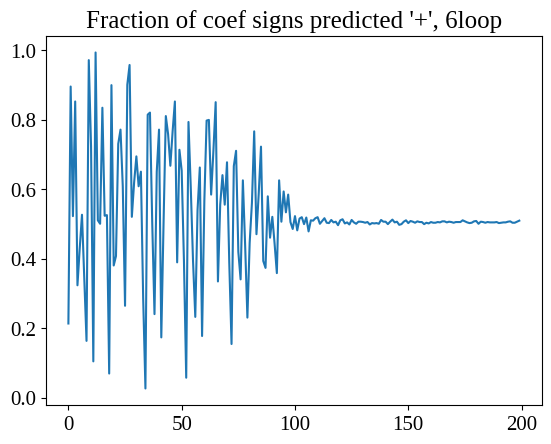

In [12]:
plt.plot(plus_pct)
plt.title("Fraction of coef signs predicted '+', 6loop")
plt.savefig("fracplus_6loop_512.png")

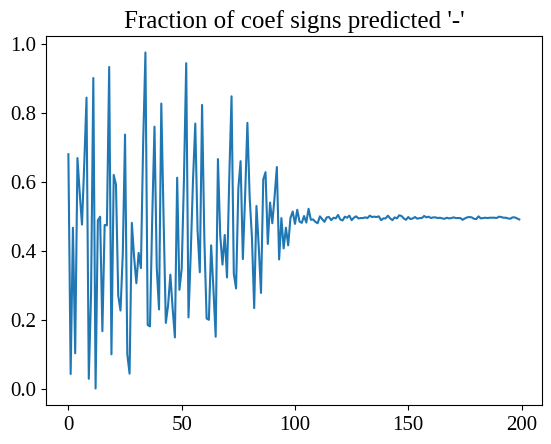

In [13]:
plt.plot(minus_pct)
plt.title("Fraction of coef signs predicted '-'")
plt.savefig("fracminus_6loop_512.png")

In [133]:
diff=[abs(plus_pct[i]-minus_pct[i]) for i in range(len(plus_pct))]

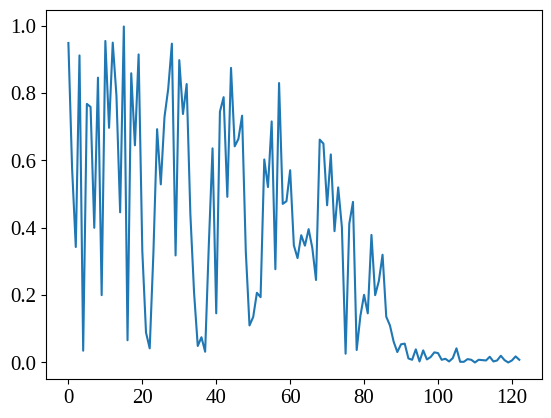

In [134]:
plt.plot(diff)

In [149]:
normplus=[]
for i in range(len(plus_pct)):
    normplus.append(abs(plus_pct[i]-tgtplus_pct[-1]))
    if abs(plus_pct[i]-tgtplus_pct[-1]) < 0.05: print(i)
    if i > 109: print(normplus[i])

4
16
21
22
35
36
37
75
78
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
0.0040000000000000036
111
0.0
112
0.0
113
0.007000000000000006
114
0.0050000000000000044
115
0.0050000000000000044
116
0.0010000000000000009
117
0.006000000000000005
118
0.0
119
0.0040000000000000036
120
0.0010000000000000009
121
0.013000000000000012
122
0.0


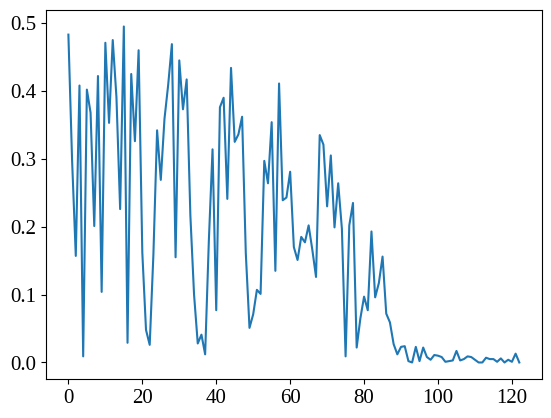

In [140]:
plt.plot(normplus)

In [156]:
from itertools import permutations
alphabet=['a','b','c','d','e','f']
dihedral_table = [list(permutations(alphabet[:3]))[i]+list(permutations(alphabet[3:]))[i] for i in range(len(alphabet))]

In [157]:
print(dihedral_table)
0,3,4
0,1=ad_flip
0,2=cf_flip
0,5=be_flip

[('a', 'b', 'c', 'd', 'e', 'f'), ('a', 'c', 'b', 'd', 'f', 'e'), ('b', 'a', 'c', 'e', 'd', 'f'), ('b', 'c', 'a', 'e', 'f', 'd'), ('c', 'a', 'b', 'f', 'd', 'e'), ('c', 'b', 'a', 'f', 'e', 'd')]


In [177]:
coefdict={}
file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.100")

pred_pluses=0
pred_minuses=0
tgt_pluses=0
tgt_minuses=0
fullcounter=0
counter=0
acc=0

with file as f:
    while True:
        next_n_lines = list(islice(f, 5))
        if not next_n_lines:
            break
        #if next_n_lines[3][0]=='1': continue
        #print(next_n_lines)
        word=next_n_lines[1][4:16]
        tgt=next_n_lines[2][4:-1]
        pred=next_n_lines[3][2:-1]
        data=[word, tgt, pred]
        if int(tgt) != 0:
            coefdict[word] = tgt

In [11]:
coefdict_full = coefdict.copy()
for key in list(coefdict.keys()):
    dhs = get_dihedral_images(key)
    #print(key,dhs)
    for dh in dhs[1:]:
        try:
            del coefdict[dh]
        except KeyError:
            continue

NameError: name 'coefdict' is not defined

In [12]:
len(coefdict)

NameError: name 'coefdict' is not defined

In [13]:
len(coefdict_full)

NameError: name 'coefdict_full' is not defined

In [14]:
for val in list(coefdict.values()):
    mykeys = [k for k,v in coefdict.items() if abs(int(v))==abs(int(val))]
    #print(val,mykeys)

NameError: name 'coefdict' is not defined

In [85]:
coefdict={}
counts=[]
import re
for epoch in range(52):
    file = open(f"../checkpoint/garrett/dumped/debug/xctzbi05g8/trainstats.boots.{epoch}")
    with file as fp:
        Lines = fp.readlines()
        for line in Lines:
            res = re.findall(r'\[.*?\]', line)[1][1:-1].split(", ")
            if res[0] > res[1]: sign = '+'
            else: sign = '-'
            res.append(sign)
            print(res)
            fracplus= (int(res[0])/(int(res[0])+int(res[1])))
            counts.append(fracplus)

['150471', '149561', '+']
['150596', '149436', '+']
['150415', '149617', '+']
['150538', '149494', '+']
['150208', '149824', '+']
['150200', '149832', '+']
['150662', '149370', '+']
['150274', '149758', '+']
['150572', '149460', '+']
['150035', '149997', '+']
['150854', '149178', '+']
['150602', '149430', '+']
['150327', '149705', '+']
['150750', '149282', '+']
['150601', '149431', '+']
['149785', '150247', '-']
['150532', '149500', '+']
['150484', '149548', '+']
['150884', '149148', '+']
['150660', '149372', '+']
['150743', '149289', '+']
['150640', '149392', '+']
['150528', '149504', '+']
['150218', '149814', '+']
['150914', '149118', '+']
['149694', '150338', '-']
['150279', '149753', '+']
['150652', '149380', '+']
['150226', '149806', '+']
['150770', '149262', '+']
['150021', '150011', '+']
['150394', '149638', '+']
['149837', '150195', '-']
['150241', '149791', '+']
['150544', '149488', '+']
['150528', '149504', '+']
['150076', '149956', '+']
['150426', '149606', '+']
['150125', '

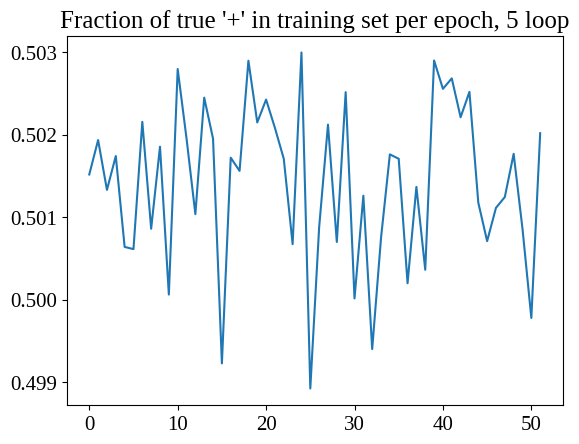

In [86]:
plt.plot(counts)
plt.title("Fraction of true '+' in training set per epoch, 5 loop")
plt.savefig("true_plus_frac_256.png")

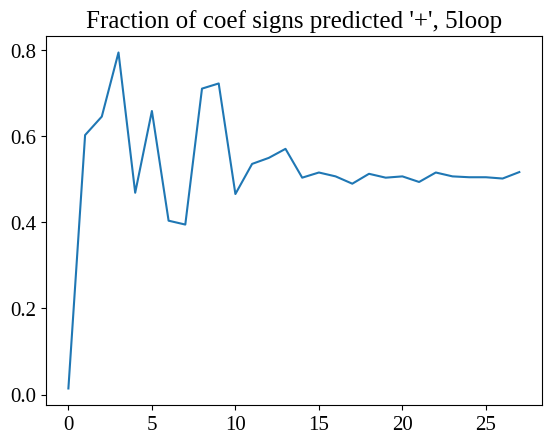

In [70]:
plt.plot(plus_pct)
plt.title("Fraction of coef signs predicted '+', 5loop")
plt.savefig("fracplus_5loop_512.png")

In [71]:
print("true,pred")
for i in range(len(counts)):
    print(counts[i]>0.5,plus_pct[i]>0.5)

true,pred
True False
True True
True True
True True
True False
True True
True False
True False
True True
True True
True False
True True
True True
True True
True True
False True
True True
True False
True True
True True
True True
True False
True True
True True
True True
False True
True True


In [53]:
def exceptions(epoch, pluspcts):
    #file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.{epoch}")
    file = open(f"../../integchecker/checkpoint_6loop/htcondor/dumped/debug/1565321/eval.valid.boots.{epoch}")
    pred_pluses=0
    pred_minuses=0
    tgt_pluses=0
    tgt_minuses=0
    fullcounter=0
    counter=0
    mypreds=[]
    acc=0
    exceptions =[]
    plus_dom = False
    if pluspcts[epoch] > 0.5: plus_dom=True
    with file as f:
        while True:
            next_n_lines = list(islice(f, 5))
            if not next_n_lines:
                break
            #if next_n_lines[3][0]=='1': continue
            #print(next_n_lines)
            word=next_n_lines[1][4:16]
            tgt=next_n_lines[2][4:-1]
            pred=next_n_lines[3][2:-1]
            data=[word, tgt, pred]
            try: num = int(pred)
            except ValueError: continue
            mypreds.append(pred)
            if int(pred) > 0:
                pred_pluses += 1
                if not plus_dom and abs(int(pred))==abs(int(tgt)):
                    exceptions.append([word[:-1], tgt, pred,'-'])
            if int(pred) < 0:
                pred_minuses += 1
                if plus_dom and abs(int(pred))==abs(int(tgt)):
                    exceptions.append([word[:-1], tgt, pred,'+'])
            if int(tgt) > 0: tgt_pluses += 1
            if int(tgt) < 0: tgt_minuses += 1
            if int(tgt) != 0:
                counter += 1
                if pred == tgt: acc += 1
            fullcounter += 1

    return exceptions,mypreds

In [3]:
def mistakes(epoch, pluspcts):
    #file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.{epoch}")
    file = open(f"../../integchecker/checkpoint_6loop/htcondor/dumped/debug/1565321/eval.valid.boots.{epoch}")
    pred_pluses=0
    pred_minuses=0
    tgt_pluses=0
    tgt_minuses=0
    fullcounter=0
    counter=0
    acc=0
    mistakes =[]
    plus_dom = False
    if pluspcts[epoch] > 0.5: plus_dom=True
    with file as f:
        while True:
            next_n_lines = list(islice(f, 5))
            if not next_n_lines:
                break
            #if next_n_lines[3][0]=='1': continue
            #print(next_n_lines)
            word=next_n_lines[1][4:16]
            tgt=next_n_lines[2][4:-1]
            pred=next_n_lines[3][2:-1]
            data=[word, tgt, pred]
            try: num = int(pred)
            except ValueError: continue
            
            if int(pred) > 0:
                pred_pluses += 1
                mistakes.append([word[:-1], tgt, pred,'-'])
            if int(pred) < 0:
                pred_minuses += 1
                mistakes.append([word[:-1], tgt, pred,'+'])
            if int(tgt) > 0: tgt_pluses += 1
            if int(tgt) < 0: tgt_minuses += 1
            if int(tgt) != 0:
                counter += 1
                if pred == tgt: acc += 1
            fullcounter += 1

    return mistakes            

0.957


4


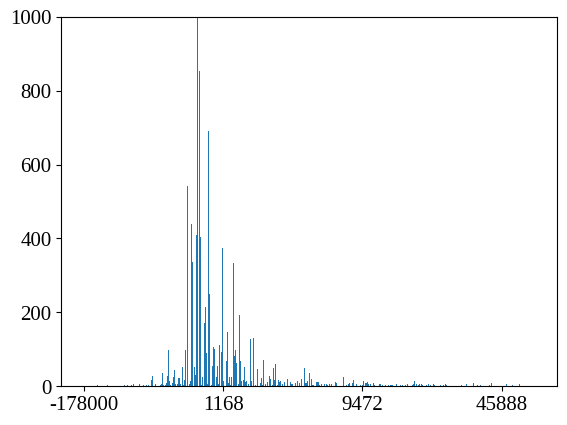

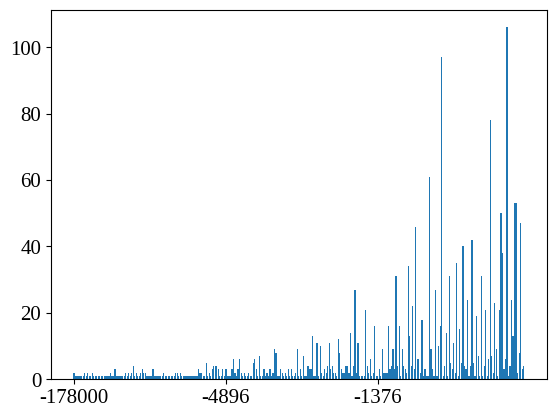

In [58]:
myexs,mypreds=exceptions(27,plus_pct)
print(plus_pct[27])
lii=[int(ex[2]) for ex in myexs]
counts=Counter(lii)
#print(list(counts.keys())[:10])
newcounts = OrderedDict(sorted(counts.items()))

lii2=[int(pred) for pred in mypreds]
counts2=Counter(lii2)
newcounts2 = OrderedDict(sorted(counts2.items()))
#newcounts2=counts2.most_common(10)

print('\n')
#print([key if val > 200 for key, val in zip(newcounts2.keys(),newcounts2.vals())])
print(i)
plt.bar(range(len(newcounts2)), newcounts2.values(), align = 'center')
plt.xticks(range(len(newcounts2)), newcounts2.keys())
ax=plt.gca()
ax.set_xticks(ax.get_xticks()[::500])
plt.ylim([0,1000])
plt.show()

#plt.bar(newcounts.keys(), newcounts.values())
#print(lii)
#nums=list(set(lii))
#nums.sort()
#plt.hist(lii,bins=nums)

plt.bar(range(len(newcounts)), newcounts.values(), align = 'center')
plt.xticks(range(len(newcounts)), newcounts.keys())
ax=plt.gca()
ax.set_xticks(ax.get_xticks()[::100])
plt.show()


In [28]:
def track_coef_tgt(epoch,coef_to_track='64'):
    #file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.{epoch}")
    file = open(f"/home/garrett/work/nozeros_out/checkpoint_6loop_nozero/htcondor/dumped/debug/1564560/eval.valid.boots.{epoch}")
    pred_pluses=0
    pred_minuses=0
    tgt_pluses=0
    trackcounter=0
    trackcounter_magcor=0
    tgt_minuses=0
    pluses_coef_to_track=0
    minuses_coef_to_track=0
    pluses_coef_to_track_magcor=0
    minuses_coef_to_track_magcor=0    
    fullcounter=0
    counter=0
    acc=0
    exceptions =[]
    with file as f:
        while True:
            next_n_lines = list(islice(f, 5))
            if not next_n_lines:
                break
            #if next_n_lines[3][0]=='1': continue
            #print(next_n_lines)
            word=next_n_lines[1][4:16]
            tgt=next_n_lines[2][4:-1]
            pred=next_n_lines[3][2:-1]
            data=[word, tgt, pred]
            try: num = int(pred)
            except ValueError: continue
            try: num2 = int(tgt)
            except ValueError: continue
            try: num_to_track = int(coef_to_track)
            except ValueError: continue
            
            if num2 == num_to_track:
                trackcounter += 1
            #print(num,num2,num_to_track)
                if int(pred) > 0:
                    pred_pluses += 1
                    pluses_coef_to_track+= 1
                    if abs(num)==abs(num2):
                        pluses_coef_to_track_magcor+= 1
                        trackcounter_magcor+=1   
                if int(pred) < 0:
                    pred_minuses += 1
                    minuses_coef_to_track+= 1
                    if abs(num)==abs(num2):
                        minuses_coef_to_track_magcor+= 1
                        trackcounter_magcor+=1   
    
    #print(pluses_coef_to_track,trackcounter)
    pred_plusround = round(pluses_coef_to_track/trackcounter,3) if trackcounter else 0
    pred_minusround = round(minuses_coef_to_track/trackcounter,3) if trackcounter else 0
    pred_plusround_magcor = round(pluses_coef_to_track_magcor/trackcounter_magcor,3) if trackcounter_magcor else 0
    pred_minusround_magcor = round(minuses_coef_to_track_magcor/trackcounter_magcor,3) if trackcounter_magcor else 0
    return pred_plusround,pred_minusround,pred_plusround_magcor,pred_minusround_magcor 

In [32]:
def track_coef_pred(epoch,coef_to_track='64'):
    #file = open(f"../../relcheck/checkpoint_6loop/htcondor/dumped/debug/171004995/eval.valid.boots.{epoch}")
    file = open(f"/home/garrett/work/nozeros_out/checkpoint_6loop_nozero/htcondor/dumped/debug/1564560/eval.valid.boots.{epoch}")
    pred_pluses=0
    pred_minuses=0
    tgt_pluses=0
    trackcounter=0
    trackcounter_magcor=0
    tgt_minuses=0
    pluses_coef_to_track=0
    minuses_coef_to_track=0
    pluses_coef_to_track_magcor=0
    minuses_coef_to_track_magcor=0    
    fullcounter=0
    counter=0
    acc=0
    exceptions =[]
    with file as f:
        while True:
            next_n_lines = list(islice(f, 5))
            if not next_n_lines:
                break
            #if next_n_lines[3][0]=='1': continue
            #print(next_n_lines)
            word=next_n_lines[1][4:16]
            tgt=next_n_lines[2][4:-1]
            pred=next_n_lines[3][2:-1]
            data=[word, tgt, pred]
            try: num = int(pred)
            except ValueError: continue
            try: num2 = int(tgt)
            except ValueError: continue
            try: num_to_track = int(coef_to_track)
            except ValueError: continue
            #print(data)
            if int(pred) > 0:
                pred_pluses += 1
                if abs(num) == abs(num_to_track):
                    pluses_coef_to_track+= 1
                    trackcounter+=1
                    if abs(num)==abs(num2):
                        pluses_coef_to_track_magcor+= 1
                        trackcounter_magcor+=1   
            if int(pred) < 0:
                pred_minuses += 1
                if abs(num) == abs(num_to_track):
                    minuses_coef_to_track+= 1
                    trackcounter+=1
                    if abs(num)==abs(num2):
                        minuses_coef_to_track_magcor+= 1
                        trackcounter_magcor+=1   

            
    pred_plusround = round(pluses_coef_to_track/trackcounter,3) if trackcounter else 0
    pred_minusround = round(minuses_coef_to_track/trackcounter,3) if trackcounter else 0
    pred_plusround_magcor = round(pluses_coef_to_track_magcor/trackcounter_magcor,3) if trackcounter_magcor else 0
    pred_minusround_magcor = round(minuses_coef_to_track_magcor/trackcounter_magcor,3) if trackcounter_magcor else 0
    return pred_plusround,pred_minusround,pred_plusround_magcor,pred_minusround_magcor 

In [35]:
def plot_track_coeff(mycoeff):
    mycoeff=str(mycoeff)
    totdiffs=0
    my_acc= []
    plus_pct=[]
    minus_pct=[]
    tgtplus_pct=[]
    tgtminus_pct=[]
    track_pluses_tgt=[]
    track_minuses_tgt=[]
    track_pluses_pred=[]
    track_minuses_pred=[]
    track_pluses_magcor_tgt=[]
    track_minuses_magcor_tgt=[]
    track_pluses_magcor_pred=[]
    track_minuses_magcor_pred=[]
    for i in range(100):
        #print(i)
        thisacc,pluspct,minuspct,tgtplus,tgtminus = signcounter(i)
        my_acc.append(thisacc)
        plus_pct.append(pluspct)
        minus_pct.append(minuspct)
        tgtplus_pct.append(tgtplus)
        tgtminus_pct.append(tgtminus)
        pred_plusround_tgt,pred_minusround_tgt,pred_plusround_magcor_tgt,pred_minusround_magcor_tgt  = track_coef_tgt(i,mycoeff)
        track_pluses_tgt.append(pred_plusround_tgt)
        track_minuses_tgt.append(pred_minusround_tgt)
        track_pluses_magcor_tgt.append(pred_plusround_magcor_tgt)
        track_minuses_magcor_tgt.append(pred_minusround_magcor_tgt)
        
        pred_plusround_pred,pred_minusround_pred,pred_plusround_magcor_pred,pred_minusround_magcor_pred  = track_coef_pred(i,mycoeff)
        track_pluses_pred.append(pred_plusround_pred)
        track_minuses_pred.append(pred_minusround_pred) 
        track_pluses_magcor_pred.append(pred_plusround_magcor_pred)
        track_minuses_magcor_pred.append(pred_minusround_magcor_pred)
    plt.plot(track_pluses_tgt)
    plt.title(f"Percent predicted +, True Coef {mycoeff}")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_plus_true_{mycoeff}_6loop_512.pdf")
    plt.show()

    plt.plot(track_minuses_tgt)
    plt.title(f"Percent predicted -, True Coef {mycoeff}")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_minus_true_{mycoeff}_6loop_512.pdf")
    plt.show()
    
    plt.plot(track_pluses_pred)
    plt.title(f"Percent predicted +, Pred Mag Abs({mycoeff})")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_plus_pred_{mycoeff}_6loop_512.pdf")
    plt.show()
    plt.plot(track_minuses_pred)
    plt.title(f"Percent predicted -, Pred Mag Abs({mycoeff})")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_minus_pred_{mycoeff}_6loop_512.pdf")
    plt.show()
    
    plt.plot(track_pluses_magcor_tgt)
    plt.title(f"Percent predicted +, True Coef {mycoeff} & Mag Correct")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_plus_true_{mycoeff}_magcor_6loop_512.pdf")
    plt.show()

    plt.plot(track_minuses_magcor_tgt)
    plt.title(f"Percent predicted -, True Coef {mycoeff} & Mag Correct")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_minus_true_{mycoeff}_magcor_6loop_512.pdf")
    plt.show()
    
    plt.plot(track_pluses_magcor_pred)
    plt.title(f"Percent predicted +, Pred Mag Abs({mycoeff}) & Mag Correct")
    plt.savefig(f"pct_plus_pred_{mycoeff}_magcor_6loop_512.pdf")
    plt.show()
    plt.plot(track_minuses_magcor_pred)
    plt.title(f"Percent predicted -, Pred Mag Abs({mycoeff}) & Mag Correct")
    plt.ylim((0.0,1.0))
    plt.savefig(f"pct_minus_pred_{mycoeff}_magcor_6loop_512.pdf")
    plt.show()

In [284]:
1088,5760,1248,64,72,36,24,192,2304,8,408,2432,1152

(1088, 5760, 1248, 64, 72, 36, 24, 192, 2304, 8, 408, 2432, 1152)

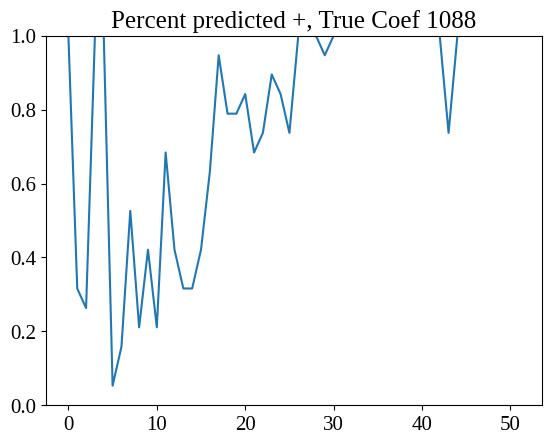

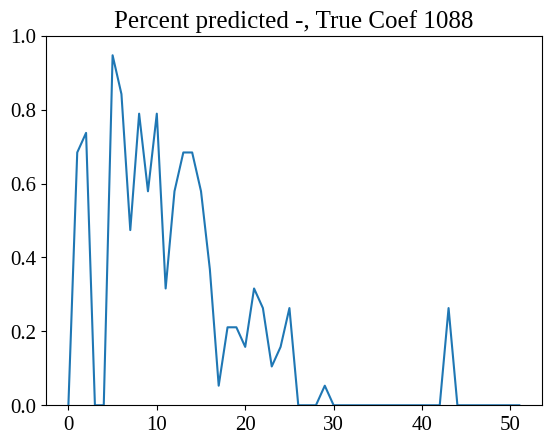

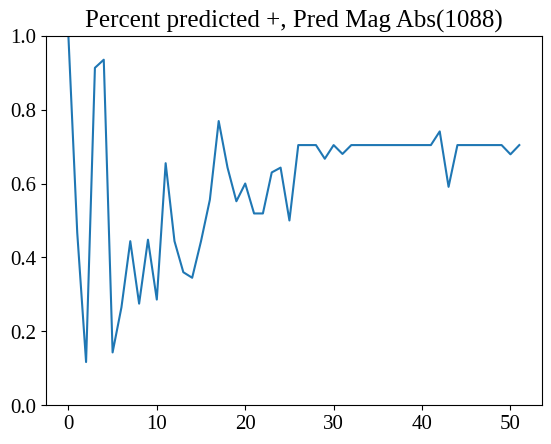

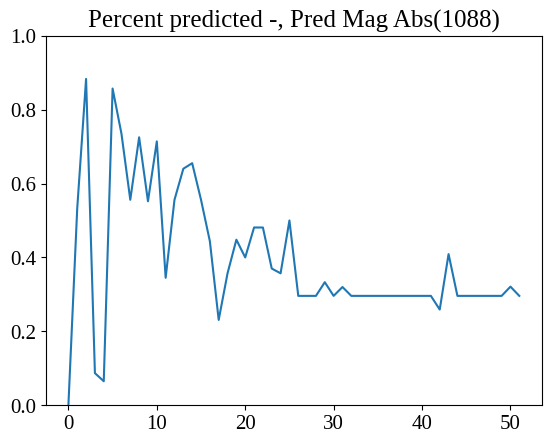

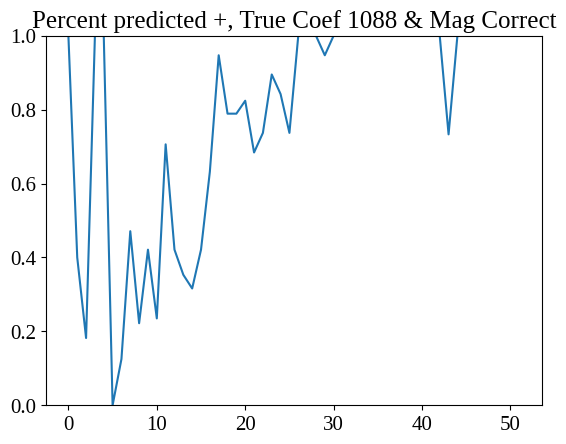

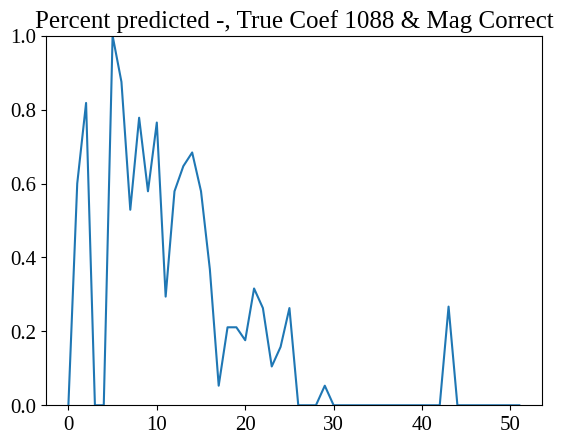

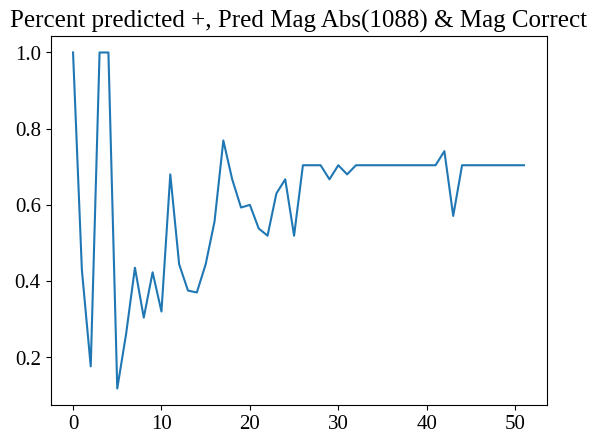

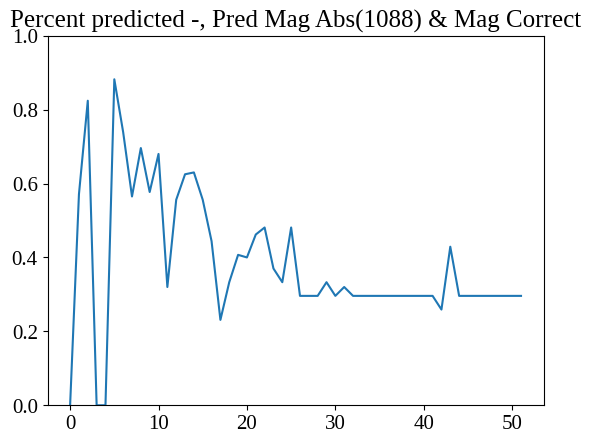

In [297]:
plot_track_coeff(1088)

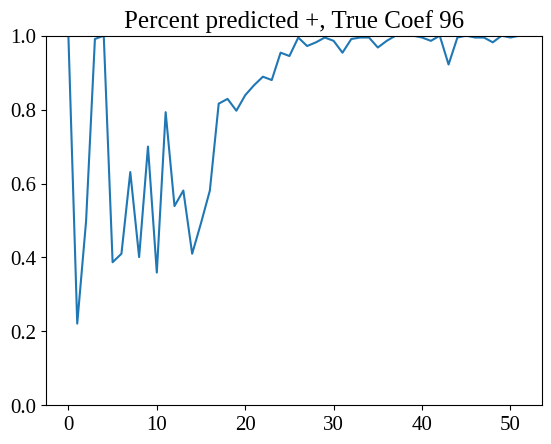

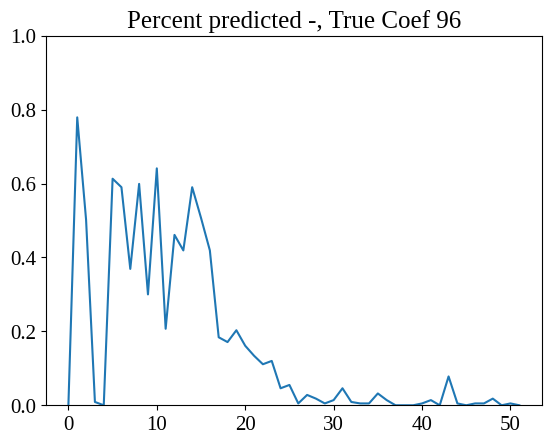

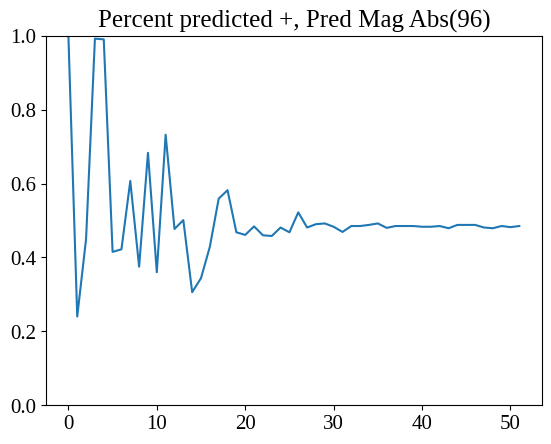

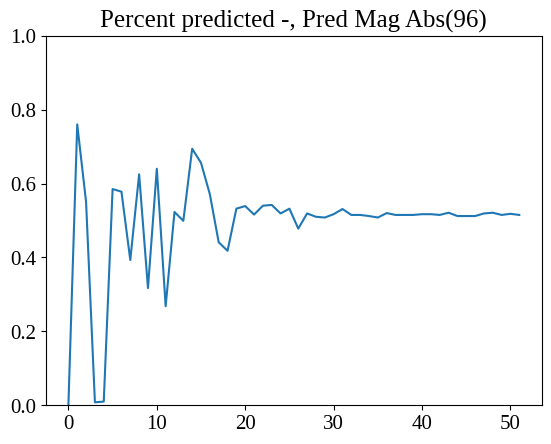

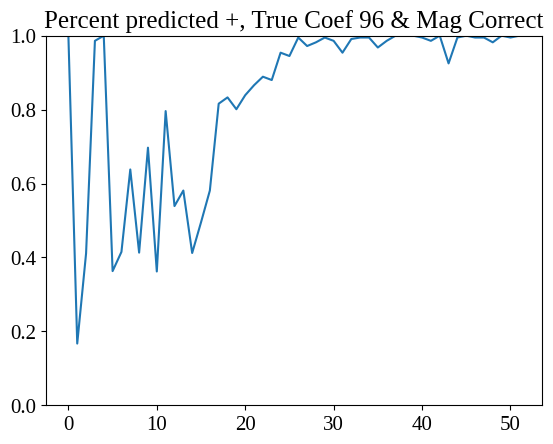

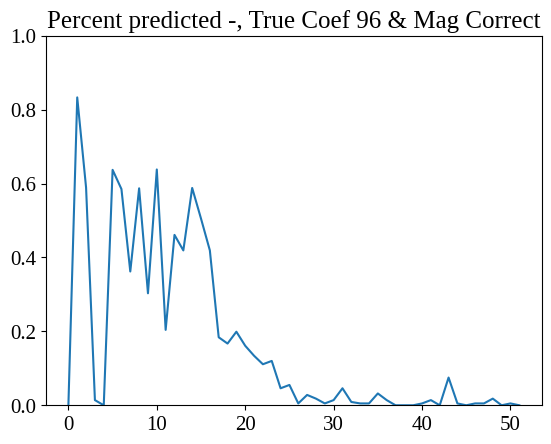

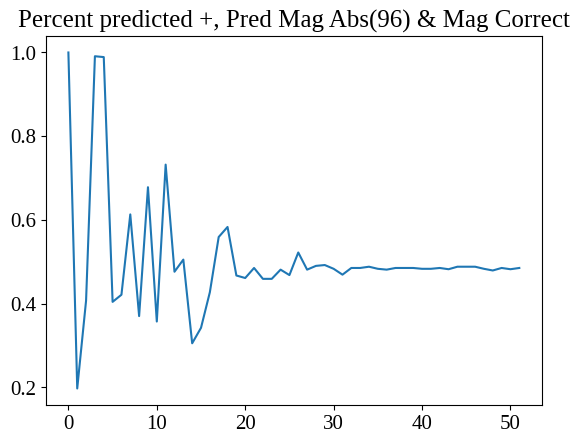

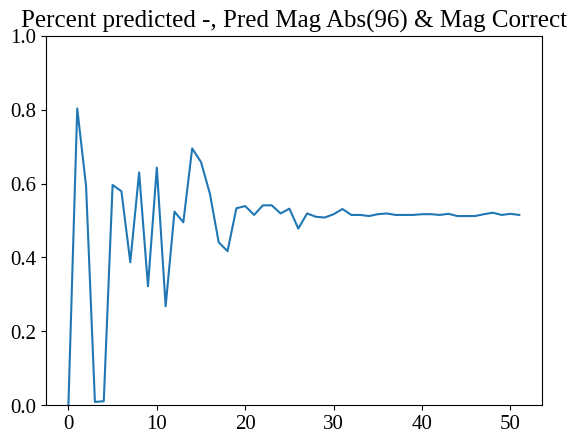

In [298]:
plot_track_coeff(96)

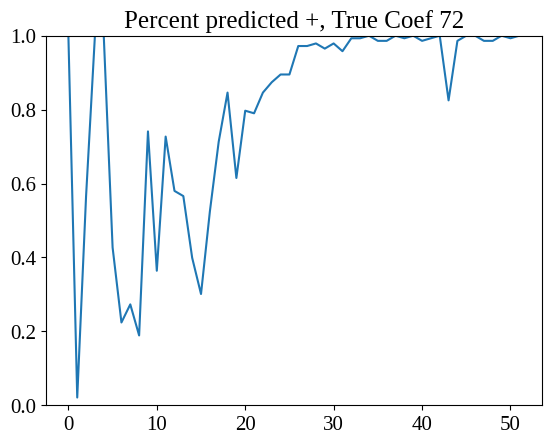

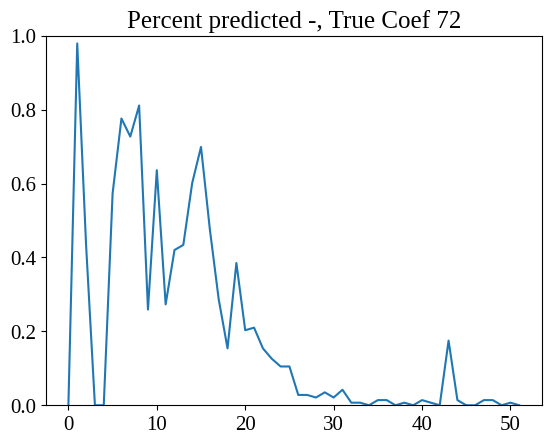

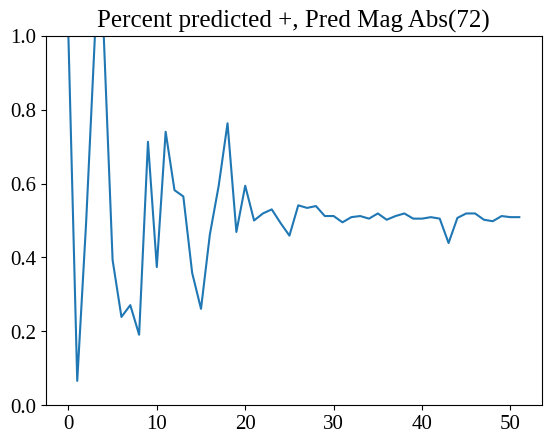

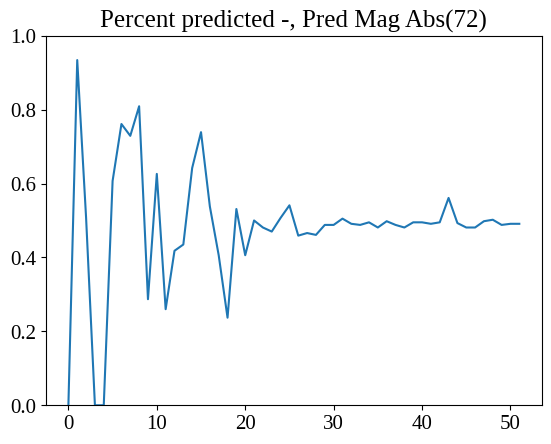

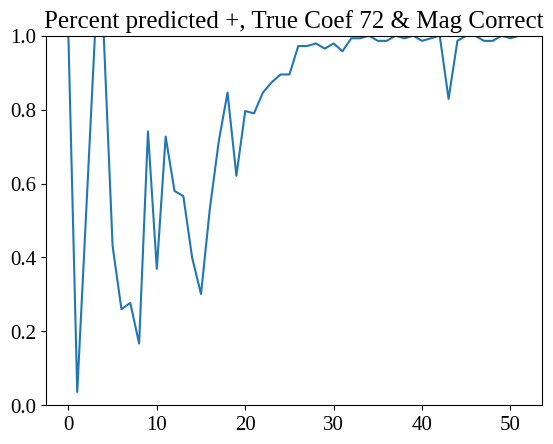

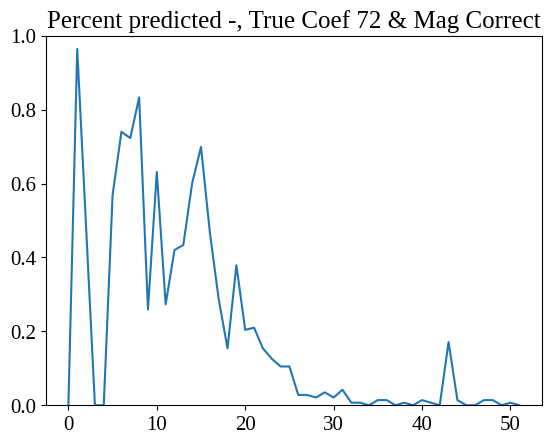

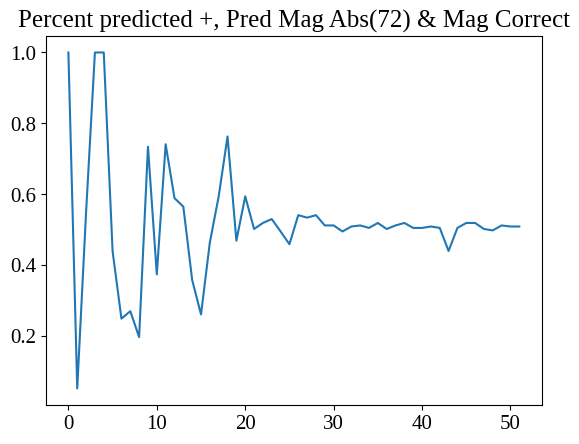

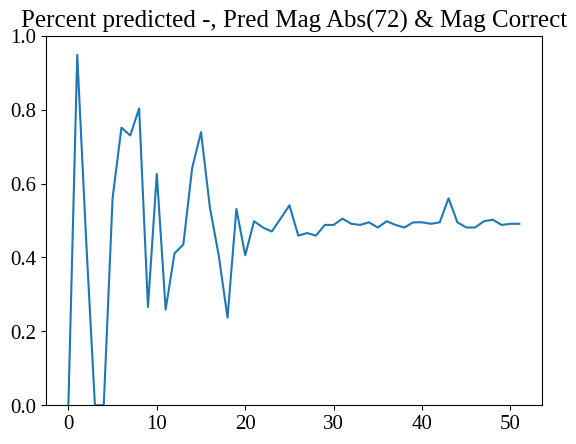

In [300]:
plot_track_coeff(72)

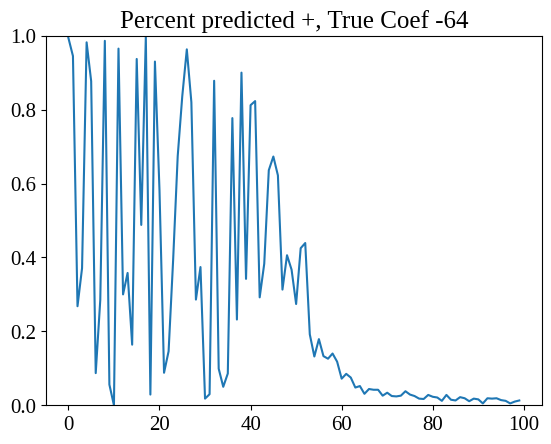

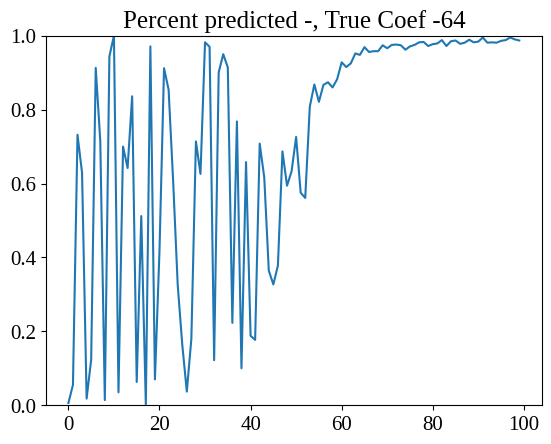

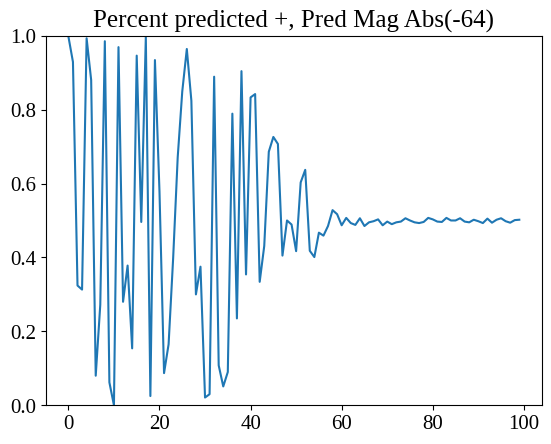

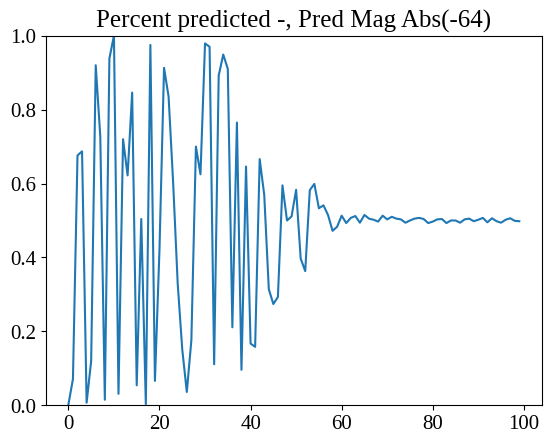

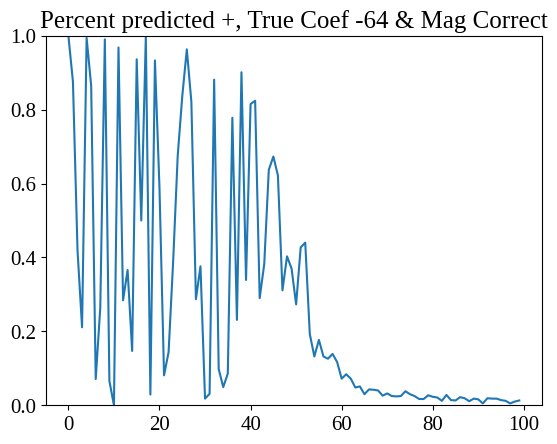

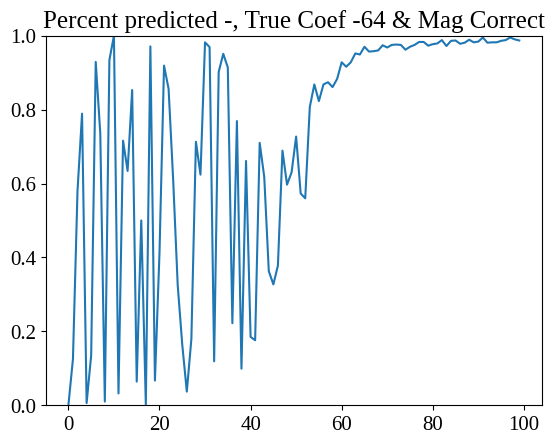

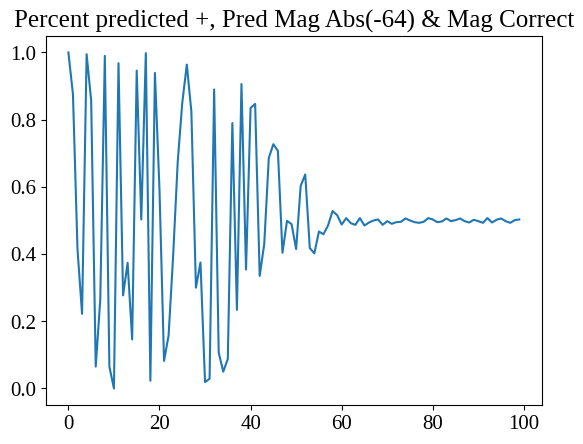

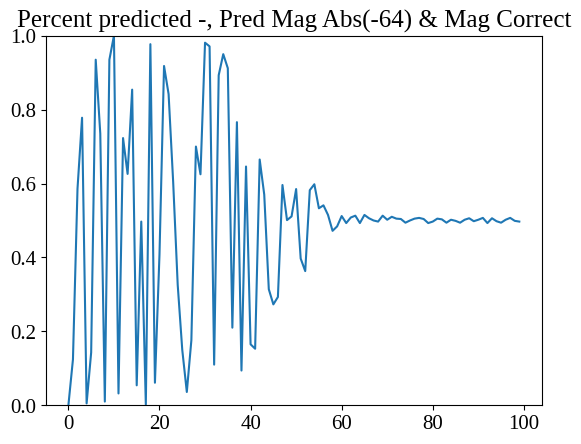

In [37]:
plot_track_coeff(-64)

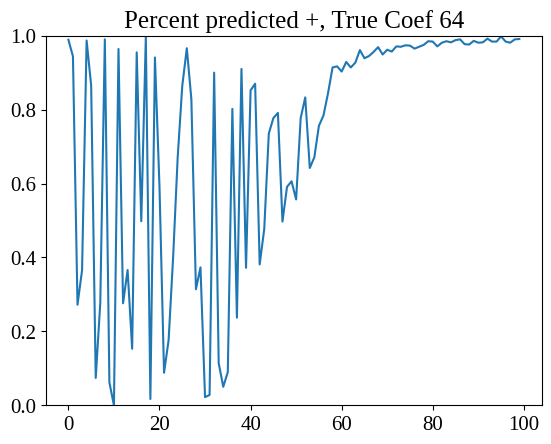

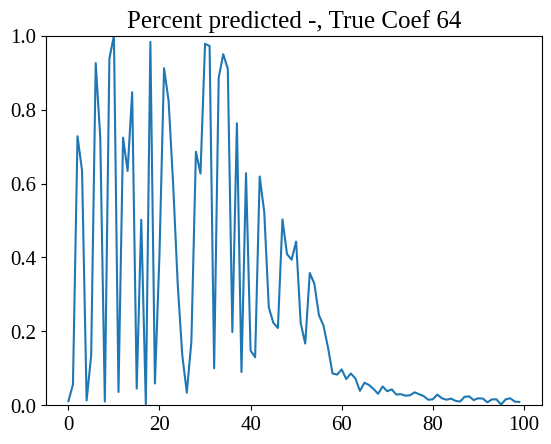

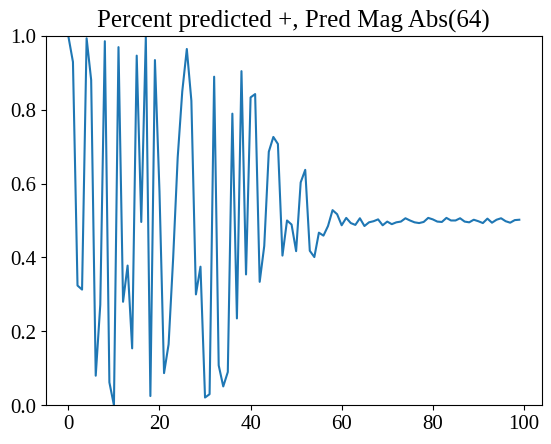

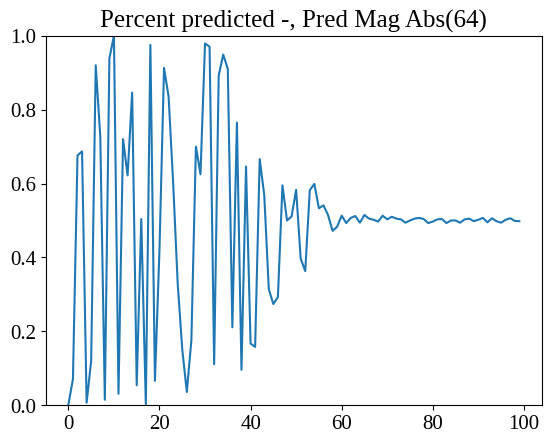

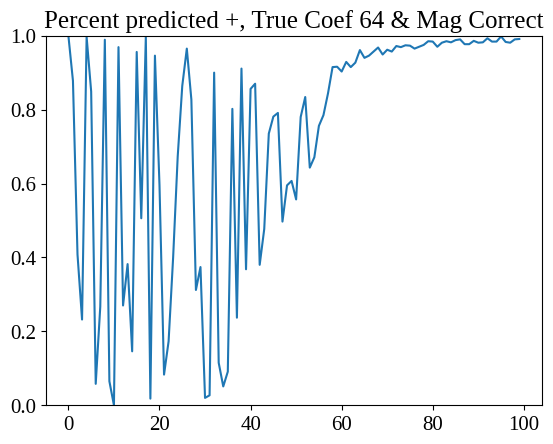

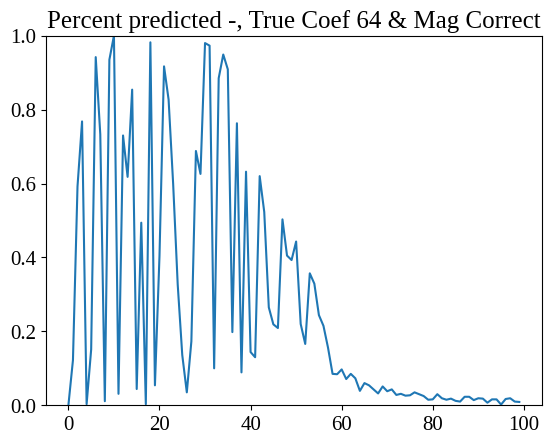

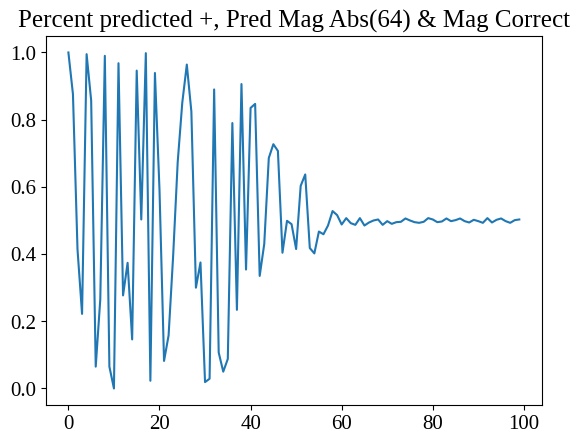

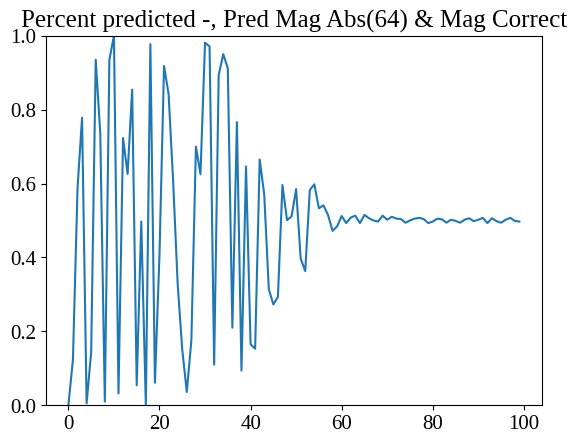

In [36]:
plot_track_coeff(64)